In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel("Telco_customer_churn.xlsx")
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [4]:
df.shape

(7043, 33)

In [5]:
"""By default, Pandas stores numbers as 64-bit integers (int64), which take up a lot of RAM. 
Because a customer's tenure in this dataset only goes up to 72 months, the data easily fits into 
an 8-bit integer (which can store numbers from -128 to 127). Downcasting to int8 reduces the memory 
footprint of this column by almost 88%, making the pipeline run much faster, especially on large
 datasets." It shows an interviewer that you care about writing efficient, production-grade code,
   not just making models work!"""
df['Tenure Months'] = df['Tenure Months'].astype('int8')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int8   
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

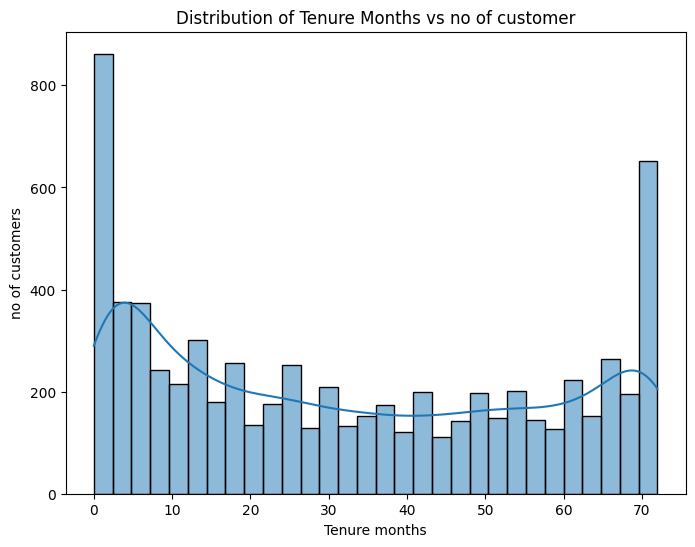

"This graph shows a 'Make or Break' customer lifecycle. Customers either leave almost immediately, or they become completely loyal and stay forever. There is almost no middle ground. This tells the business that our primary problem isn't long-term retention; it's surviving the first 5 months of customer onboarding."

In [7]:
plt.figure(figsize=(8,6))

sns.histplot(
    df['Tenure Months'],
    bins=30,
    kde=True
)
plt.xlabel("Tenure months")
plt.ylabel("no of customers")
plt.title("Distribution of Tenure Months vs no of customer")
plt.show()

#This is a classic bimodal distribution, highlighting two extreme customer segments.
'''This graph shows a 'Make or Break' customer lifecycle. Customers either leave almost immediately, or they become completely loyal and stay forever. There is almost no middle ground. This tells the business that our primary problem isn't long-term retention; it's surviving the first 5 months of customer onboarding.'''


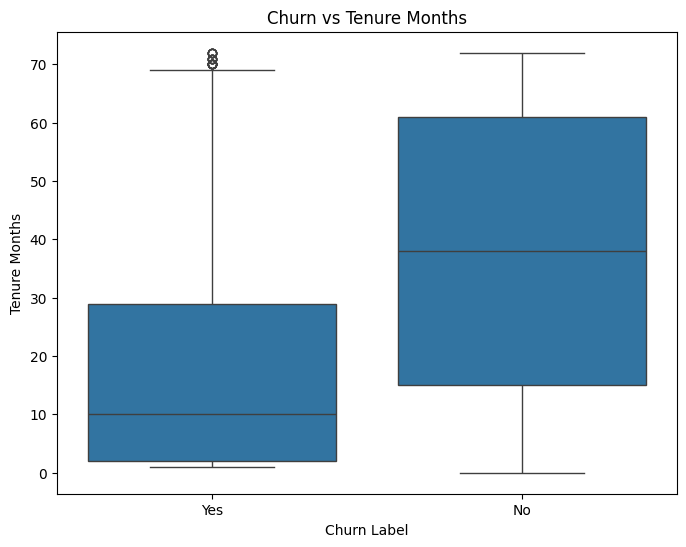

In [8]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Churn Label',
    y='Tenure Months',
    data=df
)

plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Churn vs Tenure Months')

plt.show()
#This graph shows that new customers are flight risks. If a customer is going to cancel, 
# they usually do it within#  the first 10 months. Our long-term customers 
# are highly loyal and rarely leave.

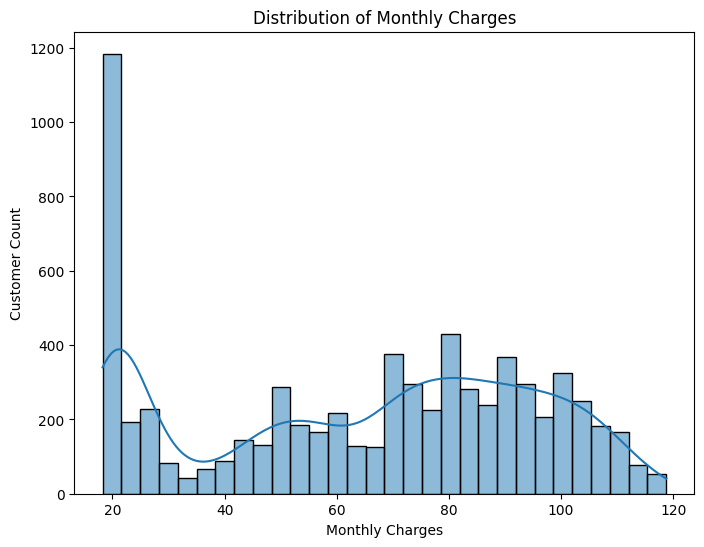

'\nWe analyze MonthlyCharges because it acts as a financial proxy for customer expectations.\n The graph shows a massive group of cheap, stable accounts at $20, and a spread of premium accounts \n over $70. In a churn pipeline, we cross-reference this feature with Churn Label because high monthly \n charges typically correlate heavily with an increased risk of churn, as premium buyers are far quicker \n to jump to a competitor offering a better discount.\n'

In [9]:
plt.figure(figsize=(8,6))
sns.histplot(
    df['Monthly Charges'],
    bins=30,
    kde=True
)

plt.xlabel('Monthly Charges')
plt.ylabel('Customer Count')
plt.title('Distribution of Monthly Charges')

plt.show()

"""
We analyze MonthlyCharges because it acts as a financial proxy for customer expectations.
 The graph shows a massive group of cheap, stable accounts at $20, and a spread of premium accounts 
 over $70. In a churn pipeline, we cross-reference this feature with Churn Label because high monthly 
 charges typically correlate heavily with an increased risk of churn, as premium buyers are far quicker 
 to jump to a competitor offering a better discount.
"""

In [10]:
df['Monthly Charges'].max()

np.float64(118.75)

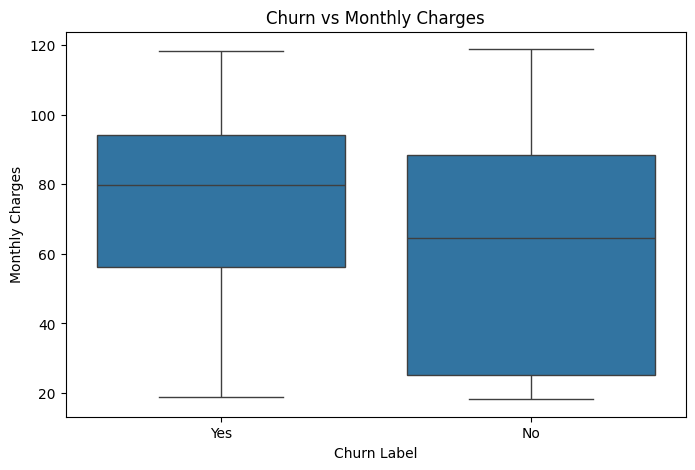

'You are absolutely right. The median monthly charge for churned customers is significantly higher\nat $80 compared to $65 for retained customers. Furthermore, the bottom quartile of the data shows us \nthat customers on cheaper, basic plans rarely churn. This tells the business that premium customers\nare highly price-sensitive and are likely churning to competitors offering cheaper rates for similar\nservices. \nthe "Yes" box doesn\'t stretch down to the $20 or $30 marks, it tells us that out \nof all the people who quit, practically \nnone of them were on a cheap plan.'

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn Label',
    y='Monthly Charges',
    data=df
)

plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('Churn vs Monthly Charges')

plt.show()

"""You are absolutely right. The median monthly charge for churned customers is significantly higher
at $80 compared to $65 for retained customers. Furthermore, the bottom quartile of the data shows us 
that customers on cheaper, basic plans rarely churn. This tells the business that premium customers
are highly price-sensitive and are likely churning to competitors offering cheaper rates for similar
services. 
the "Yes" box doesn't stretch down to the $20 or $30 marks, it tells us that out 
of all the people who quit, practically 
none of them were on a cheap plan."""

### Boolean Indexing 
-Boolean Indexing is the act of filtering a dataset using True and False values, rather than using row numbers or column names.

-Give me rows 10 through 50," you are saying, "Ask every single row a True/False question, and only give me back the rows that answer True.

-Blazing Speed: Under the hood, Pandas and NumPy process these True/False arrays using optimized C code (vectorization). It is infinitely faster than writing a for loop to check rows one by one.

-Cohort Isolation: This is how you actually do targeted machine learning or business analytics. You rarely analyze a whole dataset at once; you use boolean indexing to isolate specific cohorts (e.g., isolating only the high-risk customers).

-Human Readability: It makes your code read almost like plain English.

In [12]:
#We will use Boolean Indexing to filter our dataset into two distinct groups (Churned vs. Retained) and 
# calculate the 25th, 50th (Median), and 75th percentiles for their Monthly Charges.

'''When you use single brackets ['Monthly Charges'], Pandas pulls that single column out as a 
1-Dimensional list (called a Series). A Series does not display a table header at the top. Instead,
it prints its name at the very bottom of the output (which you can actually see in your screenshot:
Name: Monthly Charges).The Fix: If you want it to print as a clean table with the heading at the top,
you need to tell Pandas to keep it as a 2-Dimensional DataFrame. You do this by using double brackets:'''

df[df['Churn Label']=="Yes"][['Monthly Charges']]

,Monthly Charges
0,53.85
1,70.70
2,99.65
3,104.80
4,103.70
...,...
1864,59.80
1865,44.20
1866,75.75
1867,102.95


### Quantiles
This is just the math/coding version of a percentile. You just divide the percentile by 100.
The 90th percentile is the 0.90 quantile.
The 50th percentile is the 0.50 quantile.

In [13]:
'''Take all the people who quit, line up their monthly bills from cheapest to most expensive, 
and give me the exact dollar amounts at the 25%, 50%, and 75% marks'''

df[df['Churn Label']=="Yes"][["Monthly Charges"]].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [14]:
df[df['Churn Label']=="No"][["Monthly Charges"]].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


### Categorical Analysis : Contract
Categorical analysis means evaluating the distribution of text-based groups in our data. It is vital for placements because it dictates how we encode features—using One-Hot Encoding for non-ordered groups and Ordinal Encoding for ranked groups—ensuring the mathematical algorithms can ingest the data correctly without creating unnecessary data dimension traps.

In [15]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [16]:
df['Contract'].value_counts()
#to see frequency of each category

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [17]:
df['Contract'].count()
#This counts the total number of non-empty rows in that column.

np.int64(7043)

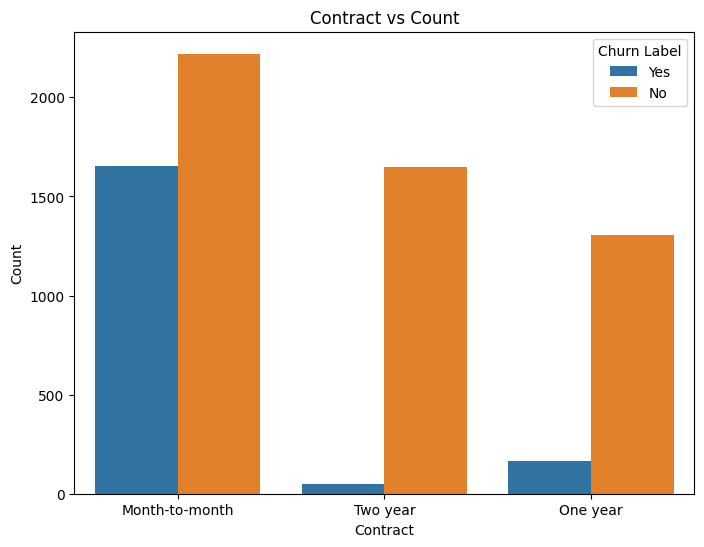

In [18]:
'''This graph explicitly proves that contract length drives customer retention. Customers on 
'Month-to-month' plans are an extremely high flight risk, making up almost our entire churned user base.
In stark contrast, once a customer commits to a 'One year' or 'Two year' contract, their churn rate 
drops to near zero. The immediate business recommendation is to aggressively incentivize month-to-month 
users to sign annual contracts, perhaps by offering a heavy discount on their first year.

This visually proves that once a customer signs a 1 or 2-year contract, the amount of people 
quitting drops to almost zero, while the number of people staying remains very high.

The lack of a lock-in period makes it too easy for month-to-month users to leave. 
The company should aggressively incentivize users to upgrade to annual contracts (e.g.,
 by offering the first month free on a 1-year plan).'''
plt.figure(figsize=(8,6))

sns.countplot(
    x='Contract',
    hue='Churn Label',
    data=df
)

plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('Contract vs Count')

plt.show()

### Categorical analysis : Internet service

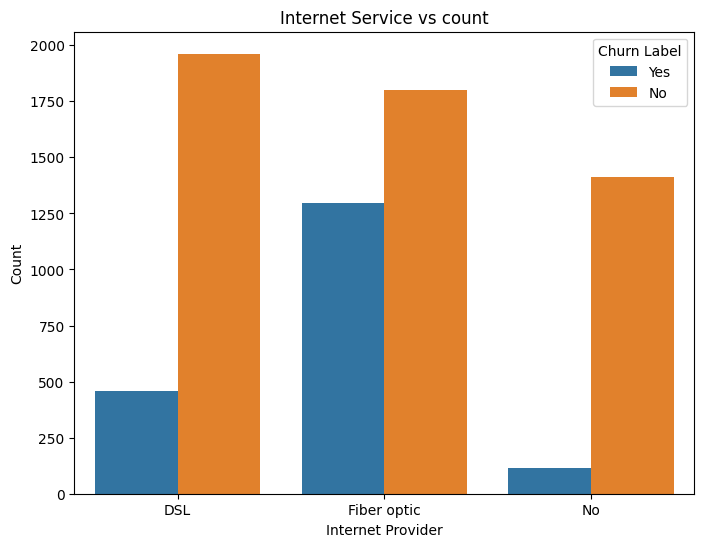

In [19]:
'''The "No Internet" Insight: You correctly identified that these customers are highly stable. 
They just want a basic phone line, so they have no reason to leave.

The "Fiber Optic" Insight: You spotted the massive blue bar. Even though DSL and Fiber Optic have 
a similar number of total users, the churn rate for Fiber Optic is alarming.

my asnwer: This graph tells us the cmount of churning happening based on the Internet provider
poeple who do not have any internet provider have no reason to churn so they stay they are not 
requiring any internet the poeple who are using fiber optics have higher churning rate maybe
because of the speed of internet so we need to check the fiber optic internet privider and 
need to know as to what is the problem

Intresting connection:::
Think back to the previous boxplot about Monthly Charges. We learned that people paying $80+ 
were churning the most. Fiber Optic is almost always the most expensive plan. You just connected 
two different variables to find the root cause: Customers are paying a premium price for Fiber Optic, 
but the quality (speed/reliability) isn't justifying the cost, so they are jumping to competitors.
'''
plt.figure(figsize=(8,6))

sns.countplot(
    x='Internet Service',
    hue='Churn Label',
    data=df
)

plt.xlabel('Internet Provider')
plt.ylabel('Count')
plt.title('Internet Service vs count')
plt.show()

### 10. Categorical Analysis: Payment Method

In [20]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

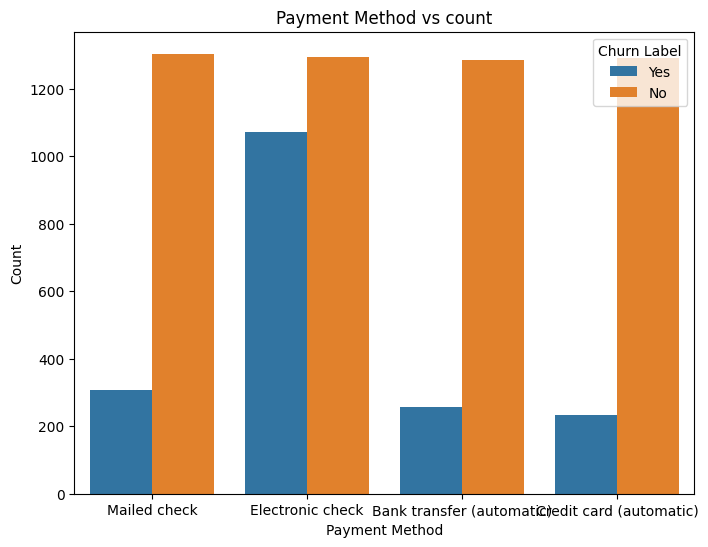

In [21]:
'''This graph highlights a major behavioral friction point. Customers paying manually via 
Electronic Check have a vastly disproportionate churn rate compared to other methods. In contrast,
automatic payment methods show excellent retention. A high-ROI business recommendation would be to
aggressively push customers toward auto-pay, perhaps by offering a $5 monthly discount for linking
a credit card or bank account, which would stabilize this volatile segment.'''

plt.figure(figsize=(8,6))

sns.countplot(
    x='Payment Method',
    hue='Churn Label',
    data=df
)

plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title('Payment Method vs count')
plt.show()

Customers using "Electronic check" are churning at an unbelievably high rate compared to everyone else. Why? Because this is a manual, high-friction process. Every single month, these customers have to actively log in, look at their total, and pay their bill. Every month they are reminded of how much they are spending, which creates a recurring psychological trigger to cancel.

"Bank transfer (automatic)" and "Credit card (automatic)". The blue bars are tiny. These are "set it and forget it" payments. The money leaves their account automatically, so they never experience the friction of actively handing over their money. They keep the service simply out of convenience and inertia.


### 11. Categorical Analysis: Tech Support

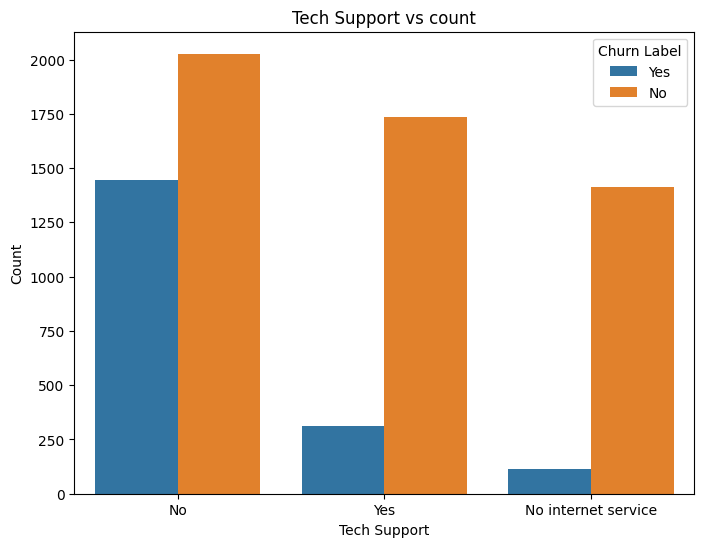

In [22]:
plt.figure(figsize=(8,6))

sns.countplot(
    x='Tech Support',
    hue='Churn Label',
    data=df
)

plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.title('Tech Support vs count')
plt.show()

The Core Red Flag ("No" Tech Support): Customers who do not have tech support show a massive surge in churn. This proves a direct link between unresolved technical frustrations and account cancellation. When users encounter bugs or outages without a lifeline, they leave.

The Retained Safeguard ("Yes" Tech Support): Enrolling in tech support dramatically drops the churn rate. Assisting customers actively creates product stickiness and loyalty.

The Hidden Friction (The "Yes" Churners): As you perfectly noted, a small portion of users with tech support still churn. This indicates that while customer service helps, it cannot entirely fix the underlying infrastructure or pricing issues—like the expensive Fiber Optic bills we uncovered earlier.

The Baseline Group ("No Internet Service"): These accounts require no technical assistance because they only use basic, highly stable phone utilities. Consequently, their churn is negligible.

### SQL aggegrate functions :Viewing avg churn months for two groups 

In [23]:
avg_tenure=df.groupby("Churn Label")["Tenure Months"].mean()
avg_tenure

#This one line of code calculates the average lifespan of a churning customer versus a loyal customer.
#It will output two simple numbers (e.g., "Yes: 17.9 months, No: 37.5 months")

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

### Numerical Correlation & Heatmap
To finalize our Exploratory Data Analysis, we will calculate the exact mean tenure of our customer base and generate a Correlation Heatmap to mathematically prove how our numerical features interact with one another.

In [24]:
'''You run a Correlation Matrix to measure how mathematically connected your numerical columns are to 
each other.Instead of guessing if two things are related, this math gives you a strict score from 
-1.0 to 1.0:

+1.0 (Perfect Positive): When one goes up, the other goes up perfectly.

-1.0 (Perfect Negative): When one goes up, the other goes down perfectly.

0.0 (No Relation): They have absolutely nothing to do with each other.

You do this before training a model to see which features strongly predict your target (Churn Value),
 and to make sure you don't have two features that are essentially identical copies of each other.'''

numerical_cols = ['Tenure Months','Monthly Charges','Churn Value', 'Churn Score', 'CLTV']
correlation_matrix = df[numerical_cols].corr()
correlation_matrix


,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


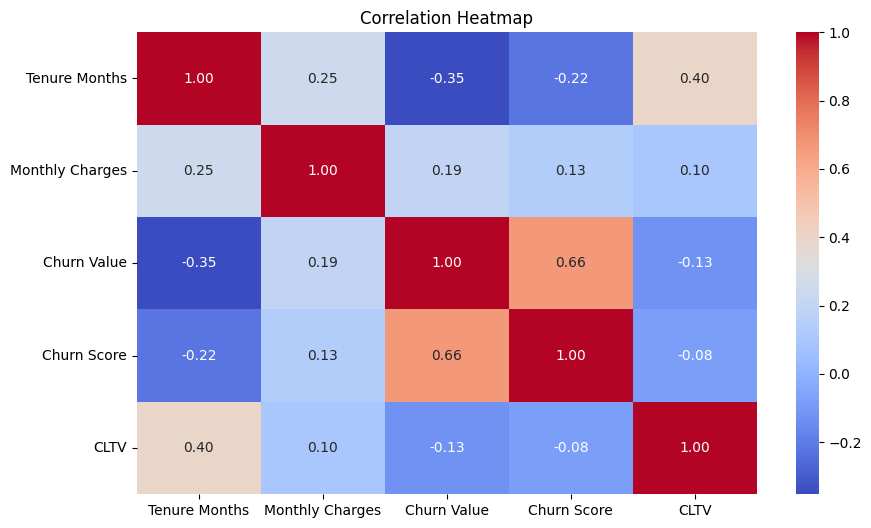

In [25]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Probability Analysis (Cross-Tabulation)
Our countplot showed a visual spike in churn for month-to-month contracts. To quantify this risk mathematically, we will generate a cross-tabulation table. 

By applying `normalize='index'`, we convert raw customer counts into **churn probabilities** for each contract tier.

In [26]:
pd.crosstab(df['Contract'], df['Churn Label'])

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


pd.crosstab is Pandas' way of creating a pivot table. You handed it two columns (Contract and Churn Label) and it simply counted how many people fall into each bucket.

The Problem: Raw numbers can be deceiving. If you have 10,000 month-to-month customers and only 100 two-year customers, the raw churn numbers will look skewed simply because one group is massively larger than the other.

By adding normalize='index', you told Pandas: "Stop giving me raw customer counts. Instead, force every row to equal 100% (or 1.0), and tell me what percentage of each row quit."

Instead of doing the math in your head, Pandas calculated the exact Churn Probability for you.

In [27]:
pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**Actionable Business Insight:**
The normalized contingency table provides exact risk metrics:
* **Critical Risk:** Month-to-month customers have an alarming **42.7% probability** of churning.
* **High Loyalty:** Securing a customer on a two-year contract drops their churn probability to a negligible **2.8%**.
* **Recommendation:** The business should prioritize converting month-to-month users into 1-year or 2-year contracts, potentially by absorbing the cost of the first month to lock them into the lower-risk tiers.

### Data Preprocessing: Type Conversion & Handling Hidden Missing Values
During our initial `df.info()` inspection, the `Total Charges` column was classified as an `object` (string) rather than a numerical `float64`. 

This happens because new customers (Tenure = 0) have their total charges recorded as blank spaces, empty string (`" "`) in the raw data. Machine Learning models require strictly numerical inputs, so we must force this column into a numeric type. 

By using `pd.to_numeric` with `errors='coerce'`, we instruct Pandas to convert the strings to floats and gracefully replace any unparseable blank spaces with standard `NaN` values, which we can then filter or impute.

To convert an object to integer::

df['Column Name'] = df['Column Name'].astype(int)
If your column has weird blank spaces or missing data (which is very common in the TotalCharges column of Telecom datasets), .astype(int) will crash. In that case, use this safer method instead:
df['Column Name'] = pd.to_numeric(df['Column Name'], errors='coerce')

You cannot use .astype(int) because Pandas doesn't know what number "Yes" should be. You must use .map() to assign the integers yourself.
-Turns 'Yes' into 1 and 'No' into 0
df['Column Name'] = df['Column Name'].map({'Yes': 1, 'No': 0})

In [28]:
df['Total Charges'] =pd.to_numeric(df['Total Charges'],errors="coerce") #forces invalid data type to become missing value
print(df['Total Charges'])

0        108.15
1        151.65
2        820.50
3       3046.05
4       5036.30
         ...   
7038    1419.40
7039    1990.50
7040    7362.90
7041     346.45
7042    6844.50
Name: Total Charges, Length: 7043, dtype: float64


In [29]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [30]:
df[df['Total Charges'].isnull()]['Tenure Months']

2234    0
2438    0
2568    0
2667    0
2856    0
4331    0
4687    0
5104    0
5719    0
6772    0
6840    0
Name: Tenure Months, dtype: int8

In [31]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [32]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [33]:
df['Total Charges'].isnull().sum() #not missing val now after fill na

np.int64(0)

In [34]:
df.drop(columns=['CustomerID','Country','Count','Zip Code','State','Lat Long','Latitude','Longitude','Churn Label','Churn Score','CLTV','Churn Reason'],inplace=True)

In [35]:
df.shape

(7043, 21)

Data Leakage: 

### One hot encoding on every object columns maybe not only on city

In [36]:
#Label encoding : one hot encoding on city column

df_encoded=pd.get_dummies(df,drop_first=True)


In [37]:
df_encoded

,Tenure Months,Monthly Charges,Total Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,City_Ahwahnee,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,False,False,False,False,False,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,0,False,True,False,False,False,False,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,0,False,False,False,False,False,False,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,0,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [38]:
df.drop(columns=['City'],inplace=True)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int8   
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [40]:
#now after deleting the city column we again encode
df_encoded=pd.get_dummies(df,drop_first=True)

In [41]:
X=df_encoded.drop('Churn Value',axis=1)
y=df_encoded['Churn Value']

#### Machine Learning implementation

In [42]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
X_train.shape


(5634, 30)

In [44]:
X_test.shape

(1409, 30)

In [45]:
X_test

,Tenure Months,Monthly Charges,Total Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
185,15,85.90,1269.55,False,False,False,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
2715,18,56.80,1074.65,True,False,True,False,True,False,True,...,False,False,False,False,False,False,False,True,False,False
3825,2,20.00,40.90,False,False,False,False,True,False,False,...,True,False,True,False,False,False,True,False,False,True
1807,6,84.20,519.15,True,True,True,False,True,False,False,...,False,False,False,True,False,False,True,False,True,False
132,40,104.80,4131.95,True,False,False,False,True,False,True,...,False,True,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6366,66,104.90,6891.45,False,True,True,True,True,False,True,...,False,True,False,True,True,False,True,False,True,False
315,19,86.00,1532.45,True,False,False,False,True,False,True,...,False,False,False,True,False,False,True,False,False,False
2439,2,90.35,190.50,False,False,True,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
5002,68,110.20,7467.50,True,False,True,True,True,False,True,...,False,True,False,True,False,True,True,False,True,False


In [46]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,random_state=42)


In [47]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
y_pred=model.predict(X_test)

In [49]:
y_pred

array([0, 0, 0, ..., 1, 0, 1], shape=(1409,))

In [50]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score
print("Accuracy : ",accuracy_score(y_test,y_pred)) #no of correct pred/total no of pred
print("recall : ",recall_score(y_test,y_pred)) #out of all actual positive cases how many my model find
print("precision : ",precision_score(y_test,y_pred)) #out of all positive pred model made how many were actually correct
print("f1 score : ",f1_score(y_test,y_pred)) # harmonic mean of p and r


Accuracy :  0.7856635911994322
recall :  0.5125
precision :  0.657051282051282
f1 score :  0.5758426966292135


 Accuracy also counts the when right pred is made for employees who stayed
 so it doesnt actually tell us anything about churning emoloyees

 recall= TP/TP+FN
 prec= T/TP+FP

In [51]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_test,y_pred)
cm

array([[902, 107],
       [195, 205]])

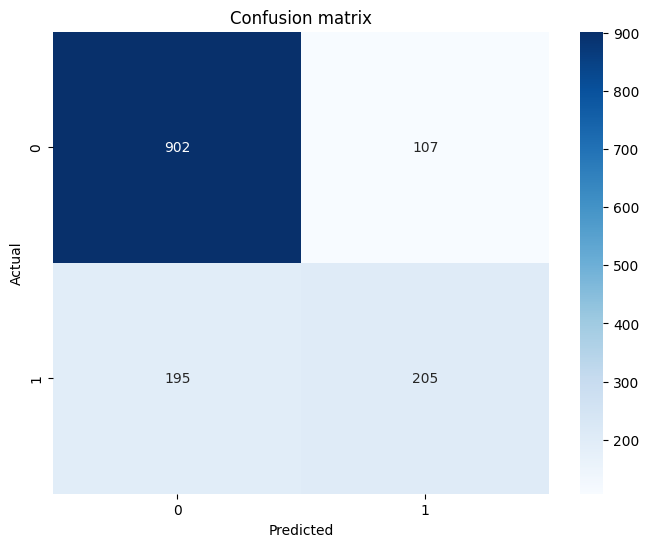

In [52]:
plt.figure(figsize=(8,6))

#heatmap
sns.heatmap(cm,annot=True, fmt="d",cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

In [53]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



Recall - out of all customers who are leaving the company(churn), my model is able to predict only 51% of them. which is a large revenue loss and companies try to maximise recall and to keep accuracy optimised 

In medical sector we dont go for the recall we go for the precision :-
precision- out of all positive predicted how many were actually true

we need to catch the people who are actually sick - so we need to knwo all the sick people my model predicted how many were actually true cause the false positives can be dangerous and false negatives too


##### How to increase recall
Approach 1- Handle class imbalance
random forest- class_weights()

In [54]:
model_balanced=RandomForestClassifier(n_estimators=100,random_state=42, class_weight="balanced")
model_balanced.fit(X_train,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


An algorithm that builds a "forest" of many decision trees and has them vote on the final prediction (Churn vs. Stay).
 n_estimators = 100 - Tells the model to build exactly 100 decision trees. 100 is the industry standard. More trees = better accuracy, but it takes your computer longer to train.

 random_state = 42 - It ensures reproducibility. If you run this code today and tomorrow, you will get the exact same numbers.

 class_weight = "balanced" - Mathematically penalizes the model for missing the minority class (the churners). This directly fixes your Confusion Matrix problem! Because you missed 195 churners (False Negatives) earlier, this setting forces the model to pay strict attention to catching churners instead of just guessing the majority "Stay" class.

In [55]:
y_pred_balanced=model_balanced.predict(X_test)

In [56]:
print("Accuracy : ",accuracy_score(y_test,y_pred_balanced)) 
print("recall : ",recall_score(y_test,y_pred_balanced)) 
print("precision : ",precision_score(y_test,y_pred_balanced)) 
print("f1 score : ",f1_score(y_test,y_pred_balanced)) 
print("Confusion_matrix : ",confusion_matrix(y_test,y_pred_balanced))
print("classification_report",print(classification_report(y_test,y_pred_balanced)))

Accuracy :  0.7920511000709723
recall :  0.5225
precision :  0.6720257234726688
f1 score :  0.5879043600562588
Confusion_matrix :  [[907 102]
 [191 209]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409

classification_report None


recall incresased by 1%
precision increased by 1%

F1 score- It is the balance point between Precision and Recall. Instead of looking at two separate numbers, the F1-Score gives you a single metric to track. If your precision is amazing but your recall is terrible, the F1-Score drops instantly. A high F1-Score means your model has found a healthy, stable middle ground.


Approach 2 : Hyper parameter tuning

In [57]:
model_hyper=RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42, class_weight="balanced" )
model_hyper.fit(X_train,y_train)
y_pred_hyper=model_hyper.predict(X_test)
print("Accuracy : ",accuracy_score(y_test,y_pred_hyper)) 
print("recall : ",recall_score(y_test,y_pred_hyper)) 
print("precision : ",precision_score(y_test,y_pred_hyper)) 
print("f1 score : ",f1_score(y_test,y_pred_hyper)) 
print("Confusion_matrix : ",confusion_matrix(y_test,y_pred_hyper))
print("classification_report",print(classification_report(y_test,y_pred_hyper)))

Accuracy :  0.7459190915542938
recall :  0.82
precision :  0.5342019543973942
f1 score :  0.6469428007889546
Confusion_matrix :  [[723 286]
 [ 72 328]]
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1009
           1       0.53      0.82      0.65       400

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.80      0.75      0.76      1409

classification_report None


Every time a decision tree goes down one level of depth, it tries to split your data in half. Because of this, the maximum possible depth is roughly tied to 2 ^ depth.
Depth 5: 2^5 = 32 rows

Depth 10: 2^10 = 1,024 rows

Depth 13: 2^13 = 8,192 rows

Depth 30: 2^30 = Over 1 billion rows
Because 8,192 is larger than your entire dataset, the tree mathematically runs out of data points to split by the time it reaches level 12 or 13.
By setting max_depth=30, you handed the algorithm a blueprint for a 30-story skyscraper, but you only gave it enough bricks to build 12 stories. It just stopped building when it ran out of data.
setting maxdepth at 5 improved it 

N_Estimators- The "Diminishing Returns" Trap: This is the most important concept to know for interviews. Accuracy does not climb forever. Going from 10 trees to 100 trees gives you a massive boost in accuracy. But going from 100 trees to 1,000 trees usually gives you almost zero extra accuracy, while making your code take 10x longer to run!

#### Recall improved by a massive number by hyper parameter tuning

### SMOTE
SMOTE stands for Synthetic Minority Over-sampling Technique. It is a popular data preprocessing algorithm used in machine learning to handle imbalanced datasets. It solves the problem of a model becoming biased toward a majority class by creating artificial data points for the minority class, rather than simply duplicating existing ones

In [ ]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# realistic synthetic churners
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#2. Train model 
rf_smote = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

#3. Test 
y_pred_smote = rf_smote.predict(X_test)
print(classification_report(y_test, y_pred_smote))


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)
Using cached sklearn_compat-0.1.6-py3-none-any.whl (22 kB)

   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1009
           1       0.58      0.72      0.64       400

    accuracy                           0.77      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.79      0.77      0.78      1409



Smote didnt work - Many of our customers who churned share the exact same traits (like similar Monthly Charges and Tenure) as customers who stayed. SMOTE simply generated "fake" churners right on top of these overlapping profiles. Instead of helping the model learn a clear difference, it just added noise and confused the model further.

Approach 3: Feature Importance analysis

In [ ]:
feature_importance=pd.DataFrame({
    'features':X.columns,
    'Importance':model_hyper.feature_importances_
})
feature_importance=feature_importance.sort_values(by='Importance',ascending=False)
print(feature_importance.tail(15))

                                  features  Importance
20        Streaming TV_No internet service    0.014723
22    Streaming Movies_No internet service    0.012710
15                       Online Backup_Yes    0.007193
26                   Paperless Billing_Yes    0.006214
5                              Partner_Yes    0.005961
27  Payment Method_Credit card (automatic)    0.003298
9                       Multiple Lines_Yes    0.003200
17                   Device Protection_Yes    0.003072
4                       Senior Citizen_Yes    0.002736
23                    Streaming Movies_Yes    0.002538
29             Payment Method_Mailed check    0.002093
7                        Phone Service_Yes    0.001786
21                        Streaming TV_Yes    0.001756
8          Multiple Lines_No phone service    0.001299
3                              Gender_Male    0.001019


In [ ]:
X_selected=X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis=1)

In [ ]:
X_train_sel,X_test_sel,y_train_sel,y_test_sel=train_test_split(
    X_selected,y,test_size=0.2,random_state=42
)

In [ ]:
rf_selected = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

rf_selected.fit(X_train_sel, y_train_sel)

y_pred_selected = rf_selected.predict(X_test_sel)

print(
    classification_report(
        y_test_sel,
        y_pred_selected
    )
)

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1009
           1       0.53      0.81      0.64       400

    accuracy                           0.74      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.74      0.75      1409



My recall reduced than hyper tuning after feature importance.

Too less maxdepth will cause underfitting

Approach 4: combination of tree and depth

In [ ]:
n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list = [5, 10, 15, 20]

results = []

for n_trees in n_estimators_list:
    for depth in max_depth_list:

        rf = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=depth,
            random_state=42,
            class_weight='balanced'
        )

        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results.append({
            'Trees': n_trees,
            'Depth': depth,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1
        })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=['Recall', 'Accuracy'],
    ascending=False
)

print(results_df.head(20))

    Trees  Depth  Accuracy  Recall  Precision  F1 Score
0     100      5  0.745919  0.8200   0.534202  0.646943
8     300      5  0.743790  0.8200   0.531605  0.645034
12    400      5  0.743790  0.8125   0.531915  0.642928
4     200      5  0.742370  0.8100   0.530278  0.640950
16    500      5  0.740951  0.8050   0.528736  0.638256
1     100     10  0.775727  0.7525   0.581081  0.655773
9     300     10  0.782825  0.7475   0.593254  0.661504
13    400     10  0.782825  0.7475   0.593254  0.661504
17    500     10  0.781405  0.7475   0.590909  0.660044
5     200     10  0.782115  0.7450   0.592445  0.660022
10    300     15  0.806246  0.6400   0.664935  0.652229
14    400     15  0.803407  0.6375   0.658915  0.648030
18    500     15  0.801987  0.6375   0.655527  0.646388
6     200     15  0.804826  0.6350   0.663185  0.648787
2     100     15  0.802697  0.6300   0.659686  0.644501
3     100     20  0.787793  0.5325   0.655385  0.587586
7     200     20  0.793471  0.5275   0.674121  0

At depth 5- i am forcing the trees to be short (Depth 5), the model is not allowed to overthink or memorize the loyal customers. Because it has class_weight='balanced', it panics and aggressively guesses 'Churn' for anyone who looks even slightly risky. Your recall skyrockets to 82%.
Because it is aggressively guessing "Churn," your Precision drops to 53%. You are catching almost all the churners, but ringing a lot of false alarms.

At depth 20- The trees got too tall. They memorized the majority class (the Stayers). Accuracy goes up to almost 80%, but your Recall completely crashes back down to 52%.

*Cross Validation, which is a way to check whether your model performs well on different parts of the dataset instead of relying on just one train-test split.*

In [ ]:
from sklearn.model_selection import cross_val_score
final_rf=RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42,class_weight='balanced')
cv_accuracy=cross_val_score(final_rf,X,y,cv=5,scoring='accuracy')

In [ ]:
cv_accuracy.mean()

np.float64(0.7528035074843538)

In [ ]:
cv_recall=cross_val_score(final_rf,X,y,cv=5,scoring='recall')

In [ ]:
cv_recall.mean()

np.float64(0.8207523906467291)

Because your average across all five splits was STILL exactly 82%, it mathematically proves that my first score wasn't a lucky. My model actually learned the underlying patterns and will perform just as well on real-world data!

#### RO AUC curve
The ROC (Receiver Operating Characteristic) curve is a graphical plot used to evaluate the performance of a binary classification model. It illustrates the trade-off between the True Positive Rate (Sensitivity) and False Positive Rate (1 - Specificity) across various decision thresholds.

In [ ]:
from sklearn.metrics import roc_curve,roc_auc_score

In [ ]:
y_prob=model_hyper.predict_proba(X_test)

In [ ]:
churn_prob=y_prob[:,1]
fpr,tpr,threshold=roc_curve(y_test,churn_prob)
auc_score=roc_auc_score(y_test,churn_prob)
print(churn_prob)

[0.72398692 0.48048266 0.35365661 ... 0.76132159 0.17247546 0.6645888 ]


a score of 0.50 means model is guessing 
a score of 1 means the model is perfect
If i randomly pick one actual churner and one actual loyal customer, your model has an 84.5% chance of correctly giving the churner a higher risk score than the loyal customer. It proves your model is highly capable of separating the high-risk customers from the safe ones!

### Threshold Tuning: 
Why used: To quickly catch more churners without retraining the model. 
What it shows: Lowering the risk cutoff (e.g., from 50% to 30%) instantly boosts Recall by trading away some Precision.

In [ ]:
y_prob = model_hyper.predict_proba(X_test)
churn_prob = y_prob[:, 1]

custom_threshold = 0.30

y_pred_custom = (churn_prob >= custom_threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.96      0.48      0.64      1009
           1       0.42      0.95      0.58       400

    accuracy                           0.62      1409
   macro avg       0.69      0.72      0.61      1409
weighted avg       0.81      0.62      0.63      1409



This increased the recall to 95% but reduced precision highly

Customer segmentation

In [ ]:
y_prob1=model_hyper.predict_proba(X)
churn_probability=y_prob1[:,1]

In [ ]:
segmentation_data=pd.DataFrame({
    'Tenure Months':X['Tenure Months'],
    'Monthly Charges':X['Monthly Charges'],
    'Total Charges':X['Total Charges'],
    'Churn Probability':churn_probability
})
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.651349
1,2,70.70,151.65,0.741109
2,8,99.65,820.50,0.684561
3,28,104.80,3046.05,0.434083
4,49,103.70,5036.30,0.362860
...,...,...,...,...
7038,72,21.15,1419.40,0.044042
7039,24,84.80,1990.50,0.214896
7040,72,103.20,7362.90,0.221993
7041,11,29.60,346.45,0.489344


### K Means
Standard scaler is used in K means

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(segmentation_data)

In [ ]:
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   0.89213575]
 [-1.23672422  0.19736523 -0.93887444  1.23893173]
 [-0.99240204  1.1595457  -0.64378925  1.02045534]
 [-0.17799476  1.33071079  0.3380854   0.05271834]
 [ 0.67713287  1.29415125  1.2161497  -0.22245576]]


We will first perform Elbow method

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

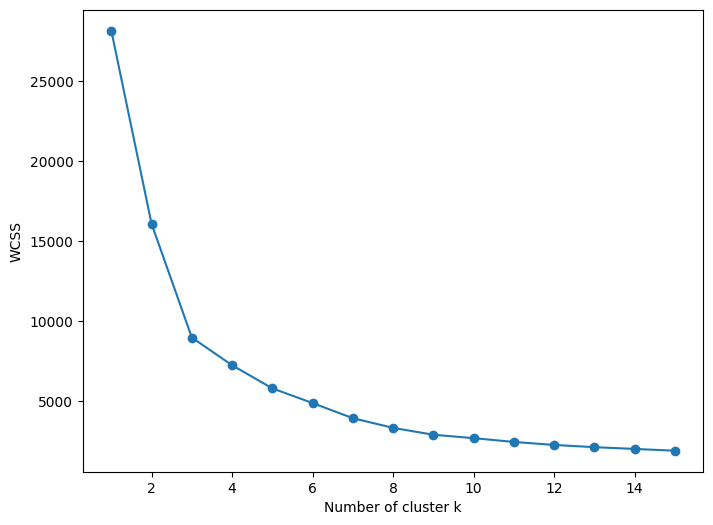

In [ ]:
from sklearn.cluster import KMeans
WCSS=[]
for k in range(1,16):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(scaled_data)
    WCSS.append(kmeans.inertia_)
    plt.figure(figsize=(8,6))
plt.plot(range(1,16),WCSS,marker='o')
plt.xlabel("Number of cluster k")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans=KMeans(n_clusters=3,random_state=42)

In [ ]:
clusters=kmeans.fit_predict(scaled_data)

In [ ]:
segmentation_data['cluster']=clusters
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,cluster
0,2,53.85,108.15,0.651349,1
1,2,70.70,151.65,0.741109,1
2,8,99.65,820.50,0.684561,1
3,28,104.80,3046.05,0.434083,2
4,49,103.70,5036.30,0.362860,2
...,...,...,...,...,...
7038,72,21.15,1419.40,0.044042,0
7039,24,84.80,1990.50,0.214896,0
7040,72,103.20,7362.90,0.221993,2
7041,11,29.60,346.45,0.489344,1


In [ ]:
cluster_summary=segmentation_data.groupby('cluster').mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
cluster,,,,
0,34.040394,29.531330,1041.129778,0.179865
1,11.206091,70.320591,870.946300,0.673069
2,58.127912,90.261603,5245.830471,0.317621


0- Budget Loyal customers

1- High risk new customer

2- Loyal customer

In [ ]:
cluster_nums={
    0:'Budget Loyal customer',
    1:'High risk new customer',
    2:'Loyal Premium Customer' 
}

In [ ]:
segmentation_data['Cluster Segment']=segmentation_data['cluster'].map(cluster_nums)
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,cluster,Cluster Segment
0,2,53.85,108.15,0.651349,1,High risk new customer
1,2,70.70,151.65,0.741109,1,High risk new customer
2,8,99.65,820.50,0.684561,1,High risk new customer
3,28,104.80,3046.05,0.434083,2,Loyal Premium Customer
4,49,103.70,5036.30,0.362860,2,Loyal Premium Customer
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.044042,0,Budget Loyal customer
7039,24,84.80,1990.50,0.214896,0,Budget Loyal customer
7040,72,103.20,7362.90,0.221993,2,Loyal Premium Customer
7041,11,29.60,346.45,0.489344,1,High risk new customer


<Axes: xlabel='Monthly Charges', ylabel='Churn Probability'>

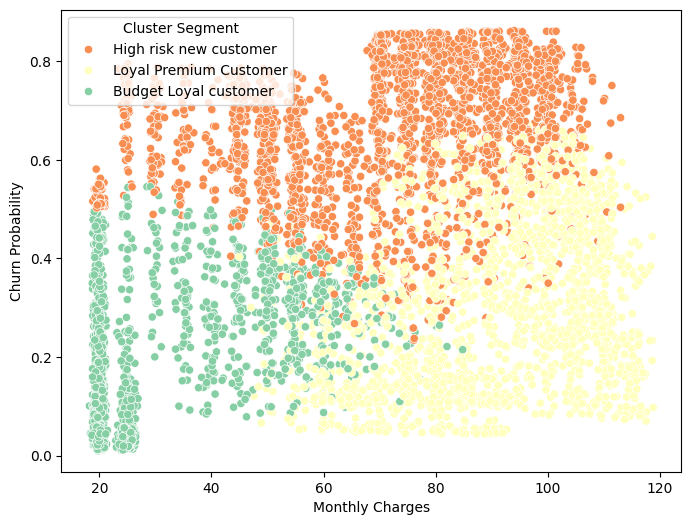

In [ ]:
#scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='Monthly Charges',y='Churn Probability',hue='Cluster Segment',data=segmentation_data,palette='Spectral')


<Axes: xlabel='Tenure Months', ylabel='Churn Probability'>

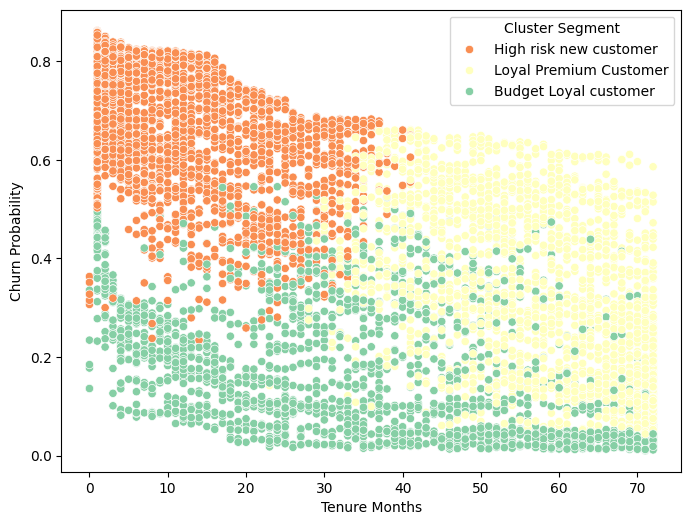

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months',y='Churn Probability',hue='Cluster Segment',data=segmentation_data,palette='Spectral')
